In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Linear(10, 2)
inputs = torch.randn(4, 10)
targets = torch.randn(4, 2)

criterion  = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum=0.9)


optimizer.zero_grad()
loss = criterion(model(inputs), targets)
loss.backward()
optimizer.step()

In [3]:
import torch

def narrow_valley_loss(w):
    """
    A simple 2D loss function creating a narrow valley.
    High curvature on w[0] (steep walls), low curvature on w[1] (flat floor).
    """
    return (100 * w[0]**2) + (w[1] - 5)**2

# ---------------------------------------------------------
# 1. Implementation from scratch (The exact math)
# ---------------------------------------------------------
w_custom = torch.tensor([-2.0, -2.0], requires_grad=True)
velocity = torch.zeros_like(w_custom) # Initialize velocity v_0 = 0

learning_rate = 0.01
momentum_coeff = 0.9

print("Custom Momentum Steps:")
for step in range(5):
    loss = narrow_valley_loss(w_custom)
    loss.backward()
    
    with torch.no_grad(): # Do not track gradient operations for the update
        # Math: v_{t+1} = \mu v_t + \nabla L(w_t)
        velocity = (momentum_coeff * velocity) + w_custom.grad
        
        # Math: w_{t+1} = w_t - \eta v_{t+1}
        w_custom -= learning_rate * velocity
        
        # Clear gradient for the next step (optimizer.zero_grad())
        w_custom.grad.zero_()
        
    print(f"Step {step+1} | w: {w_custom.data.numpy().round(4)} | v: {velocity.numpy().round(4)}")

# ---------------------------------------------------------
# 2. PyTorch Native Implementation
# ---------------------------------------------------------
w_native = torch.tensor([-2.0, -2.0], requires_grad=True)

# PyTorch encapsulates the velocity state internally
optimizer = torch.optim.SGD([w_native], lr=learning_rate, momentum=momentum_coeff)

print("\nPyTorch Native Steps:")
for step in range(5):
    optimizer.zero_grad()
    loss = narrow_valley_loss(w_native)
    loss.backward()
    optimizer.step()
    
    print(f"Step {step+1} | w: {w_native.data.numpy().round(4)}")

Custom Momentum Steps:
Step 1 | w: [ 2.   -1.86] | v: [-400.  -14.]
Step 2 | w: [ 1.6    -1.5968] | v: [ 40.   -26.32]
Step 3 | w: [-1.96  -1.228] | v: [356.     -36.8816]
Step 4 | w: [-1.244  -0.7715] | v: [-71.6    -45.6494]
Step 5 | w: [ 1.8884 -0.2452] | v: [-313.24    -52.6274]

PyTorch Native Steps:
Step 1 | w: [ 2.   -1.86]
Step 2 | w: [ 1.6    -1.5968]
Step 3 | w: [-1.96  -1.228]
Step 4 | w: [-1.244  -0.7715]
Step 5 | w: [ 1.8884 -0.2452]


In [ ]:
import torch

def generate_analytical_trajectories(batch_size, seq_len, dt=1.0):
    """
    Generates 3D trajectories using analytical kinematic equations.
    Output shape: (batch_size, seq_len, 3)
    """
    # 1. Initialize states
    # P0: Initial position in 3D space (X, Y, Z)
    p0 = torch.rand(batch_size, 1, 3) * 1000 
    
    # V0: Initial velocity (e.g., -50 to 50 m/s)
    v0 = (torch.rand(batch_size, 1, 3) - 0.5) * 100 
    
    # A: Constant acceleration (e.g., gravity on the Z axis)
    a = torch.zeros(batch_size, 1, 3)
    a[:, :, 2] = -9.81 

    # 2. Create time vector
    # Shape: (1, seq_len, 1) to broadcast across batches and 3D coordinates
    time_steps = torch.arange(seq_len, dtype=torch.float32).view(1, -1, 1) * dt

    # 3. Apply the kinematic equation across all dimensions simultaneously
    position_term = p0
    velocity_term = v0 * time_steps
    acceleration_term = 0.5 * a * (time_steps ** 2)
    
    trajectories = position_term + velocity_term + acceleration_term
    
    return trajectories

# Generate 128 trajectories, each 100 steps long, sampled every 0.1 seconds
batch_trajectories = generate_analytical_trajectories(batch_size=128, seq_len=100, dt=0.1)

batch_trajectories

tensor([[[ 504.9944,  765.7421,  808.4119],
         [ 505.2139,  769.3733,  810.3960],
         [ 505.4334,  773.0045,  812.2819],
         ...,
         [ 526.2828, 1117.9686,  544.1130],
         [ 526.5023, 1121.5999,  536.5814],
         [ 526.7217, 1125.2311,  528.9517]],

        [[ 744.6755,   75.5690,  833.0298],
         [ 743.9196,   76.7816,  835.4966],
         [ 743.1638,   77.9941,  837.8652],
         ...,
         [ 671.3576,  193.1872,  615.5520],
         [ 670.6017,  194.3998,  608.5030],
         [ 669.8459,  195.6124,  601.3560]],

        [[ 775.6353,  714.3380,  806.3742],
         [ 770.8273,  718.9301,  805.1684],
         [ 766.0193,  723.5222,  803.8646],
         ...,
         [ 309.2603, 1159.7686,  232.6616],
         [ 304.4523, 1164.3607,  221.9401],
         [ 299.6443, 1168.9528,  211.1205]],

        ...,

        [[ 465.5746,  823.4423,   78.5153],
         [ 463.7416,  822.9525,   82.0628],
         [ 461.9086,  822.4628,   85.5121],
         ...,


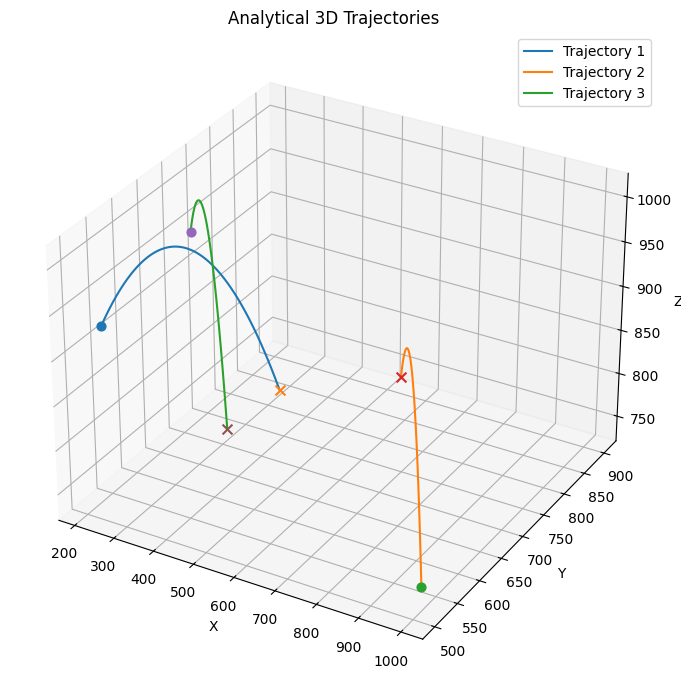

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Generate a smaller batch for visualization
vis_traj = generate_analytical_trajectories(batch_size=3, seq_len=100, dt=0.1)
time = torch.arange(vis_traj.shape[1], dtype=torch.float32) * 0.1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i in range(vis_traj.shape[0]):
    traj = vis_traj[i].detach().cpu().numpy()
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], label=f'Trajectory {i + 1}')
    ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], marker='o', s=40)
    ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], marker='x', s=50)

ax.set_title('Analytical 3D Trajectories')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
plt.show()